# Diabetes Prediction
## Goal:
### Compare multiple ML algorithms and identify the best for diabetes predicition.
## ML Models:
### Logistic Regression, Decision Tree, Random Forest, Naive Bayes and XGBoost.
## Evaluation metrics:
### Accuracy, Precision, Recall, F1-score, ROC-AUC.

## Importing Required Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency , shapiro
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import accuracy_score , classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Loading Data and Data Description


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/patients_data.xlsx')
df.head()

,Treatment,Age,Gender,Obesity,Diabetes,Hypertension,Blood_pressure,Smoker,Cholestrol,Cholestrol2,Angina,FBS,Hemglobin,CRP1,CRP2,CRP3,AgeGroups,haemoglobingroups
0,2,52,1,2,2,2,1,2,2,3,2,111,11,23,19,17,2,1
1,2,51,2,2,2,2,1,2,2,3,2,115,12,18,14,12,2,1
2,2,47,2,2,1,2,2,2,2,3,2,100,11,25,21,19,1,1
3,2,56,2,2,2,2,2,1,2,3,1,117,14,18,14,12,2,2
4,2,50,1,2,2,2,1,2,2,3,2,111,11,20,18,14,1,1


### Variables Description
| Variable   | Description |
|------------|-------------|
|Treatement  | 1=Treatement B, 2=Treatement A|
|Gender| 1=Female, 2=Male|
|Obesity| 1=Yes, 2=No|
|Diabetes|1=Yes, 2=No|
|Hypertension|1=Yes, 2=No|
|Blood Pressure|1=Abnormal, 2=Normal|
|Smoker|1=Yes, 2=No|
|Cholestrol|1=High, 2=Normal|
|Cholestrol2|1=High, 2=Mild, 3=Normal|
|Angina|1=Yes, 2=No|
|Age Group|1=age<50, 2=age>=50|
|Haemoglobin Groups|2=value<12, 1=value>=12|


## EDA

### Conversion to a readable format

In [ ]:
df_read=df.copy()
df_read['Gender']=df_read['Gender'].map({1:'Female',2:'Male'})
df_read['Obesity']=df_read['Obesity'].map({1:'Yes',2:'No'})
df_read['Diabetes']=df_read['Diabetes'].map({1:'Yes', 2:'No'})
df_read['Hypertension']=df_read['Hypertension'].map({1:'Yes', 2:'No'})
df_read['Blood_pressure']=df_read['Blood_pressure'].map({1:'Abnormal', 2:'Normal'})
df_read['Smoker']=df_read['Smoker'].map({1:'Yes', 2:'No'})
df_read['Cholestrol']=df_read['Cholestrol'].map({1:'High', 2:'Normal'})
df_read['Cholestrol2']=df_read['Cholestrol2'].map({1:'High', 2:'Mild', 3:'Normal'})
df_read['Angina']=df_read['Angina'].map({1:'Yes', 2:'No'})
df_read['AgeGroups']=df_read['AgeGroups'].map({1:'less than 50', 2:'More than 50'})
df_read['haemoglobingroups']=df_read['haemoglobingroups'].map({2:'less than 12', 1:'More than or equal to 12'})

### Data Overview


In [ ]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Treatment          800 non-null    int64
 1   Age                800 non-null    int64
 2   Gender             800 non-null    int64
 3   Obesity            800 non-null    int64
 4   Diabetes           800 non-null    int64
 5   Hypertension       800 non-null    int64
 6   Blood_pressure     800 non-null    int64
 7   Smoker             800 non-null    int64
 8   Cholestrol         800 non-null    int64
 9   Cholestrol2        800 non-null    int64
 10  Angina             800 non-null    int64
 11  FBS                800 non-null    int64
 12  Hemglobin          800 non-null    int64
 13  CRP1               800 non-null    int64
 14  CRP2               800 non-null    int64
 15  CRP3               800 non-null    int64
 16  AgeGroups          800 non-null    int64
 17  haemoglobingroup

### Checking for any class imbalance.

In [ ]:
df_read['Diabetes'].value_counts()
df_read['Diabetes'].value_counts(normalize=True)

,proportion
Diabetes,
No,0.91375
Yes,0.08625


### Univariate Analysis

<Axes: xlabel='Gender', ylabel='count'>

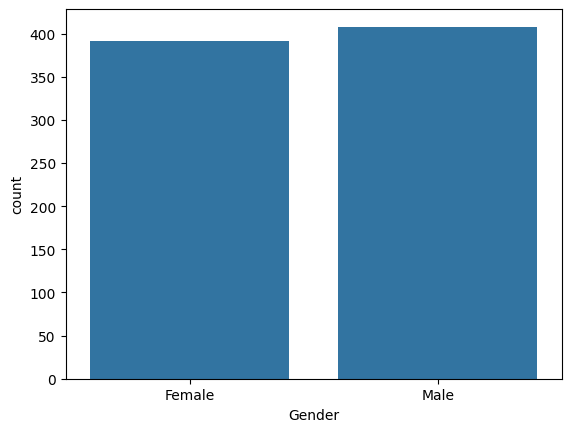

In [ ]:
sns.countplot(x='Gender', data=df_read)

Patient data consist of 49% females and 51% males.

<Axes: xlabel='Angina', ylabel='count'>

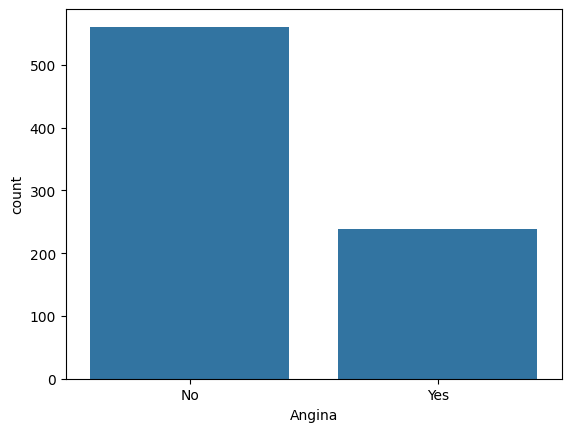

In [ ]:
sns.countplot(x='Angina' , data=df_read)

Close to 31% of patients have Angina.

<Axes: xlabel='Obesity', ylabel='count'>

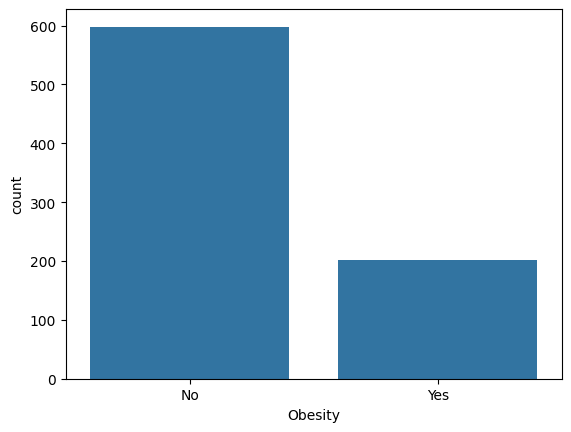

In [ ]:
sns.countplot(x='Obesity', data=df_read)


25% of patients are obese.


,count
Hypertension,
No,733
Yes,67


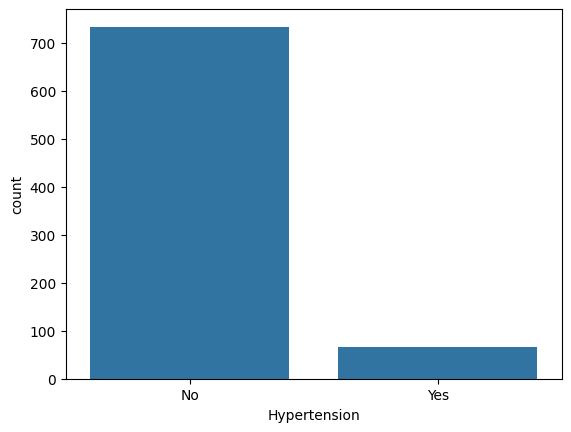

In [ ]:
sns.countplot(x='Hypertension', data=df_read)
df_read['Hypertension'].value_counts()

Around 8.375% of patients have Hypertension.

,count
Smoker,
No,671
Yes,129


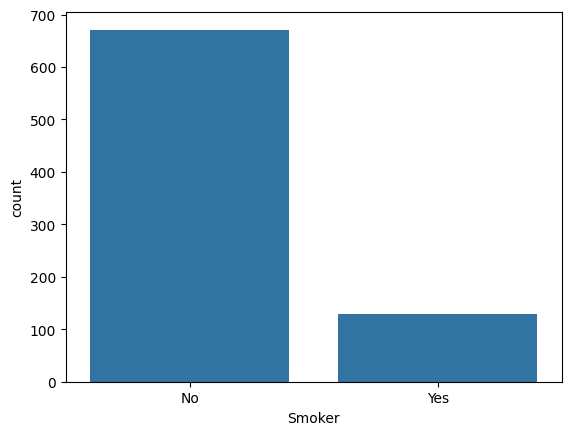

In [ ]:
sns.countplot(x='Smoker', data=df_read)
df_read['Smoker'].value_counts()

Around 16.1% of our patients are smokers.

,count
Cholestrol,
Normal,489
High,311


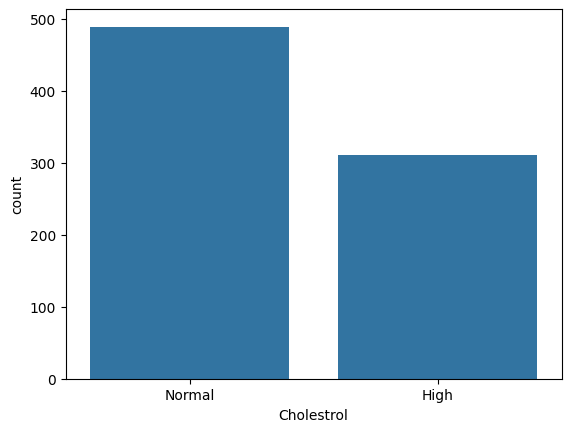

In [ ]:
sns.countplot(x='Cholestrol', data=df_read)
df_read['Cholestrol'].value_counts()

Around 38.8% of our patients got high Cholestrol

,count
haemoglobingroups,
More than or equal to 12,666
less than 12,134


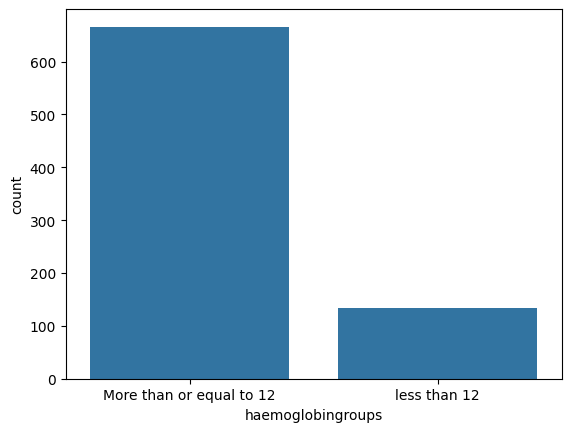

In [ ]:
sns.countplot(x='haemoglobingroups', data=df_read)
df_read['haemoglobingroups'].value_counts()


 16.75% patients got low Haemoglobin.

,count
AgeGroups,
More than 50,726
less than 50,74


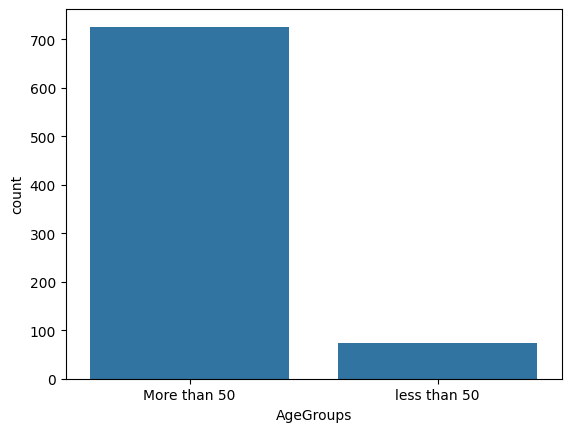

In [ ]:
sns.countplot(x='AgeGroups' , data=df_read)
df_read['AgeGroups'].value_counts()

90.9% of our patients are over 50 years of age.

### Identifying Outliers

<Axes: xlabel='Hemglobin'>

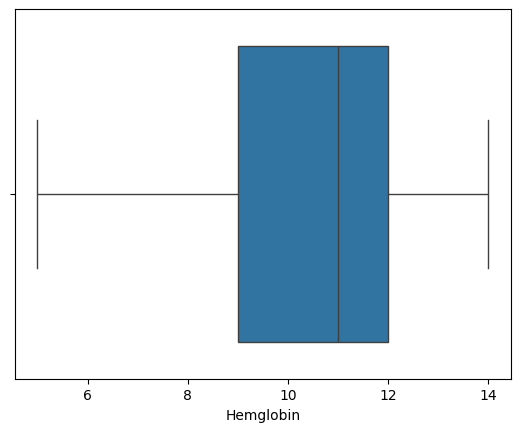

In [ ]:
sns.boxplot(x=df['Hemglobin'])

No outliers in patient's Hemoglobin data.

<Axes: ylabel='Age'>

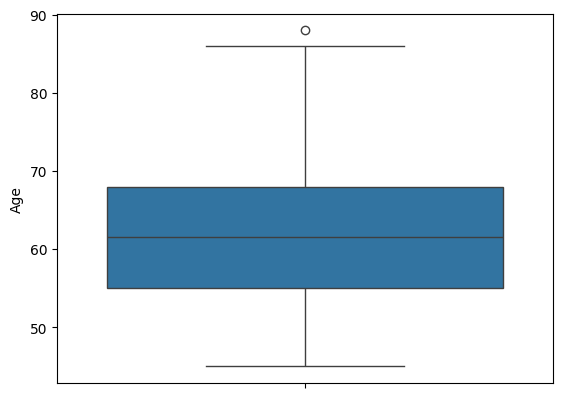

In [ ]:
sns.boxplot(df['Age'])

one  outlier in patient's age data.

<Axes: ylabel='FBS'>

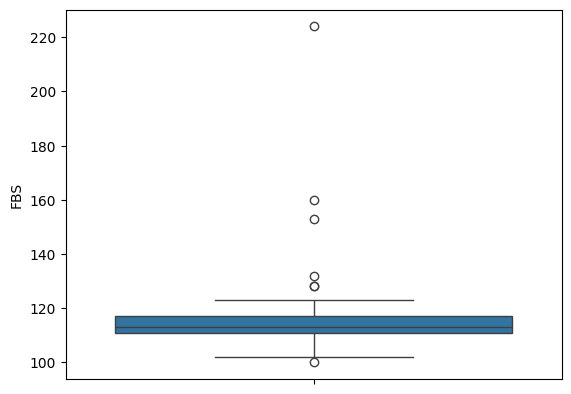

In [ ]:
sns.boxplot(df_read['FBS'])

Six outliers in patient's FBS data.

### Checking Normality of Numeric Data.

p = 1.5944120031871102e-08


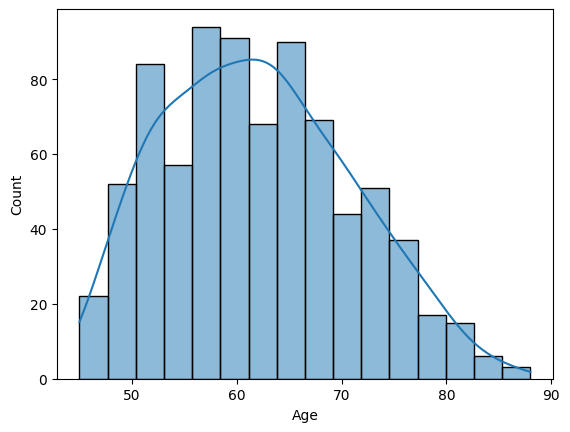

In [ ]:
sns.histplot(df['Age'] , kde=True)
stats, p = shapiro(df['Age'])
print(f"p = {p}")

The distribution of Age is not normal, it is positively skewed and deducted from the Shapiro Wilk test of normality p value is
<0.001(<0.05).

p=1.0971731040739655e-14


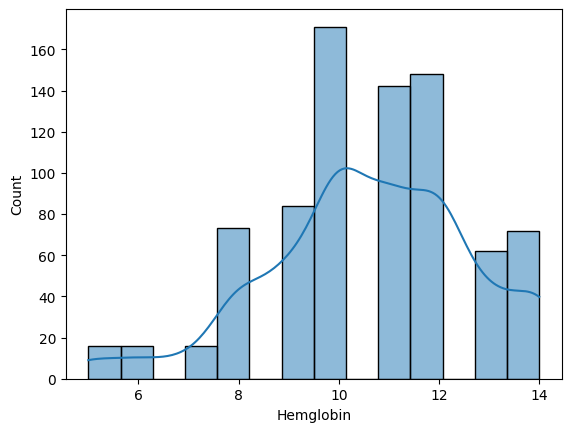

In [ ]:
sns.histplot(df['Hemglobin'], kde=True)
stat ,p=shapiro(df['Hemglobin'])
print(f"p={p}")

The distribution of Hemoglobin is not normal, as observable from above graph and deducted from the Shapiro Wilk test of normality p value is <0.001(<0.05).

p=2.0659155457063536e-41


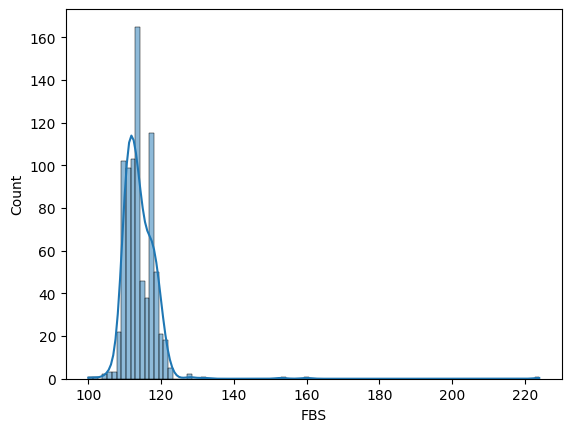

In [ ]:
sns.histplot(df_read['FBS'], kde=True)
stats, p =shapiro(df['FBS'])
print(f"p={p}")

The distribution of FBS is not normal as observable from the graph and deducted from the Shapiro Wilk test of normality p value is <0.001(<0.05).

### Bivariate Analysis

p=0.00850265235550655



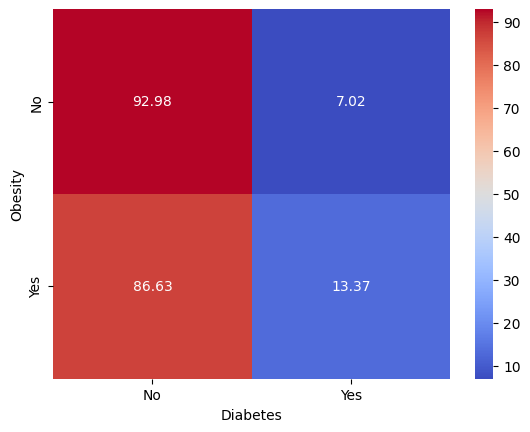

In [ ]:

ct=(pd.crosstab(df_read['Obesity'], df_read['Diabetes'], normalize='index')*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
contingency= pd.crosstab(df['Obesity'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}\n")

Heatmap shows that 13.37% of obese individuals are diabetic compared to 7.02% of non-obese individuals.<br>  p-value of 0.0085(<0.05), indicates statistically significant relation between obesity and diabetes. <br>This suggests obesity might be important risk factor for diabetes.

p=8.804118928997358e-152



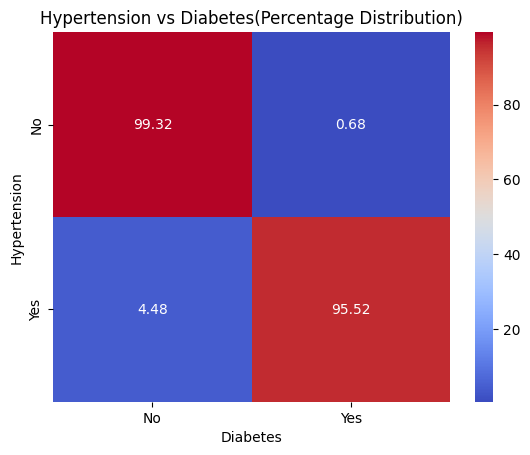

In [ ]:

ct=(pd.crosstab(df_read['Hypertension'], df_read['Diabetes'], normalize='index')*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Hypertension vs Diabetes(Percentage Distribution)")
contingency= pd.crosstab(df['Hypertension'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}\n")


Heatmap shows strong relationship between diabetes and hypertension. 95.52% of hypertension patients are diabetic, whereas ony 0.68% wihout hypertension are diabetic.<br>p-value of <0.0001(<0.05), confirms the statistical significance of the relation.<br>This suggests hypertension is a strong risk factor for diabetes.

p=0.8301894853576417


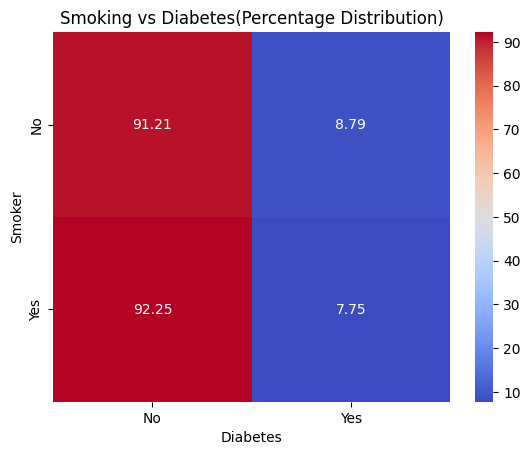

In [ ]:

ct=(pd.crosstab(df_read['Smoker'], df_read['Diabetes'], normalize='index')*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Smoking vs Diabetes(Percentage Distribution)")
contingency= pd.crosstab(df['Smoker'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}")

Heatmap shows the proportions of diabetic individuals among smokers and non-smokers are almost identical.<br>p-vlaue of 0.83(>0.05), shows no statistical signifinat association between smoking and diabetes.<br>Therefore, smoking does not appear to be a strong predictor of diabetes.

p=0.5482711510595745


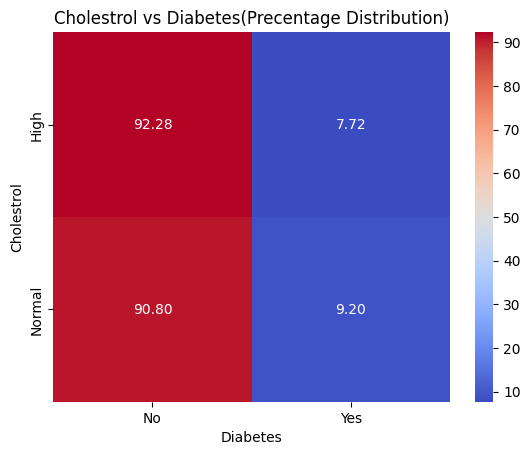

In [ ]:
ct=(pd.crosstab(df_read['Cholestrol'], df_read['Diabetes'], normalize='index')*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cholestrol vs Diabetes(Precentage Distribution)")
contingency=pd.crosstab(df['Cholestrol'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}")

Heatmap shows that percentage of diabetic individuals having high and normal cholestrol is almost identical.<br>Further the p value of 0.548(>0.05) shows no statistical significant relation between cholestrol and diabetes. Therefore, high cholestrol does not appear to be a strong predictor for diabetes.

p=1.0


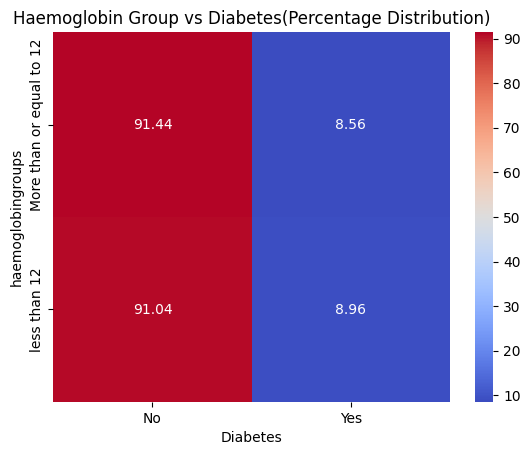

In [ ]:
ct=(pd.crosstab(df_read['haemoglobingroups'], df_read['Diabetes'], normalize="index")*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Haemoglobin Group vs Diabetes(Percentage Distribution)")
contingency=pd.crosstab(df['haemoglobingroups'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}")

Heatmap shows both the haemoglobin groups have almost identical number of diabetic people.<br> The p value of 1.0(>0.05), further confirms that there is no statistically significant relation between haemoglobin level and diabetes.
<br> Therefore, Having low haemoglobin does not appear a strong predictor of Diabetes.

p=0.2102205941759615


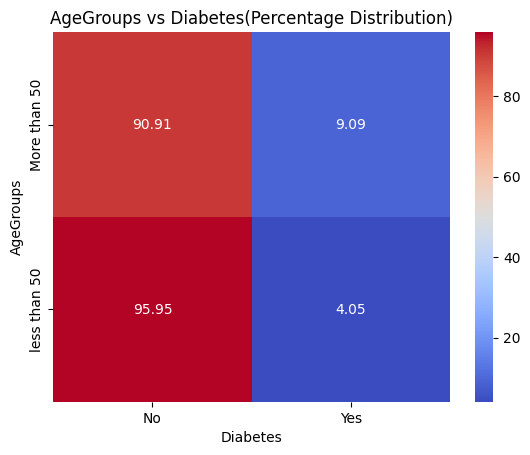

In [ ]:
ct=(pd.crosstab(df_read['AgeGroups'], df_read['Diabetes'], normalize="index")*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("AgeGroups vs Diabetes(Percentage Distribution)")
contingency=pd.crosstab(df['AgeGroups'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}")

Heatmap shows that both the age groups have identical number of diabetic patients.<br> Further the p value of 0.21(>0.05), shows there is no statistically significant relation between age group and diabetes.<br>Therefore, belonging to a specific age group is not a predictor of Diabetes.

p=1.3847671446578314e-13


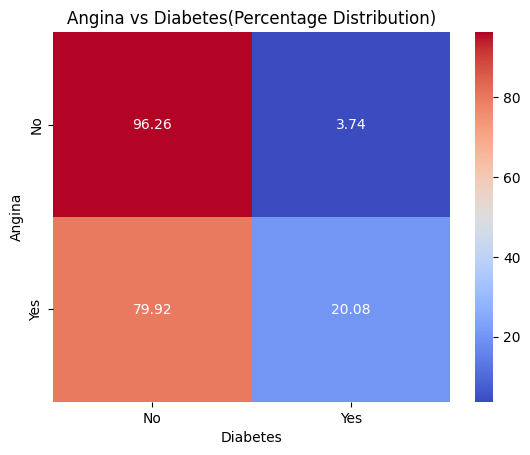

In [ ]:
ct=(pd.crosstab(df_read['Angina'], df_read['Diabetes'], normalize="index")*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Angina vs Diabetes(Percentage Distribution)")
contingency=pd.crosstab(df['Angina'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}")

Heatmap shows that a person having Angina is five times more likely to have diabetes. <br> Further the p value being <0.001(<0.05), shows there is a statistically significant relation between Angina and diabetes.<br>Therefore, having Angina is a strong predictor of Diabetes.

p=0.01463876230198667


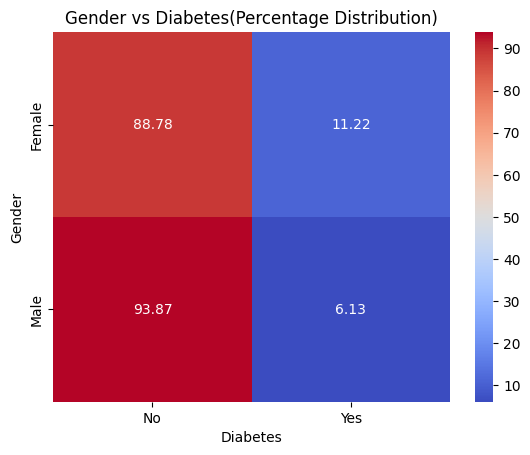

In [ ]:
ct=(pd.crosstab(df_read['Gender'], df_read['Diabetes'], normalize="index")*100).round(2)
sns.heatmap(ct, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Gender vs Diabetes(Percentage Distribution)")
contingency=pd.crosstab(df['Gender'], df['Diabetes'])
chi2,p,_,_=chi2_contingency(contingency)
print(f"p={p}")

Heatmap shows that being a female leads to increased chances of diabetes.<br>Further the p value of 0.014(<0.05), shows there exists a statistically significant relation between Gender and Diabetes.<br>Therefore, Gender could be an indicator of diabetes.

### Multivariate Analysis

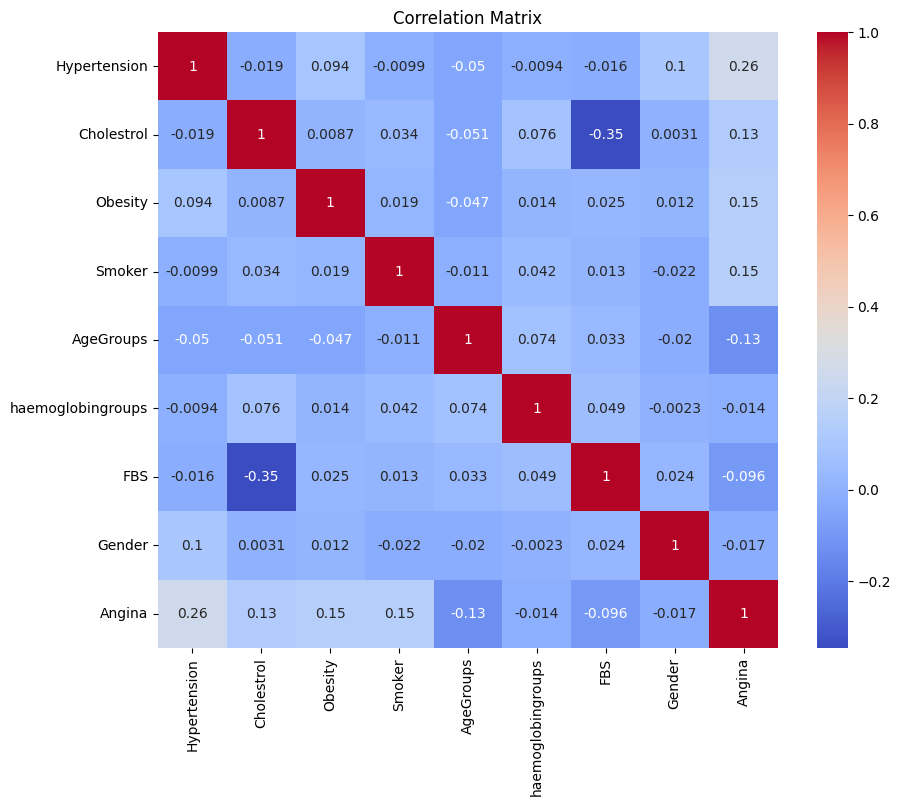

In [ ]:
plt.figure(figsize=(10,8))
cols=['Hypertension', 'Cholestrol', 'Obesity', 'Smoker', 'AgeGroups', 'haemoglobingroups', 'FBS', 'Gender', 'Angina']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The above correlation matrix shows there is no strong linear relationship among the independent variables, as all correlation coeffcients are close to zero, Thus, multicollinearilty is not a problem in our dataset.<br>Some weak correlation obsereved between variables like hypertension and obesity, but they are statistically insignificant.

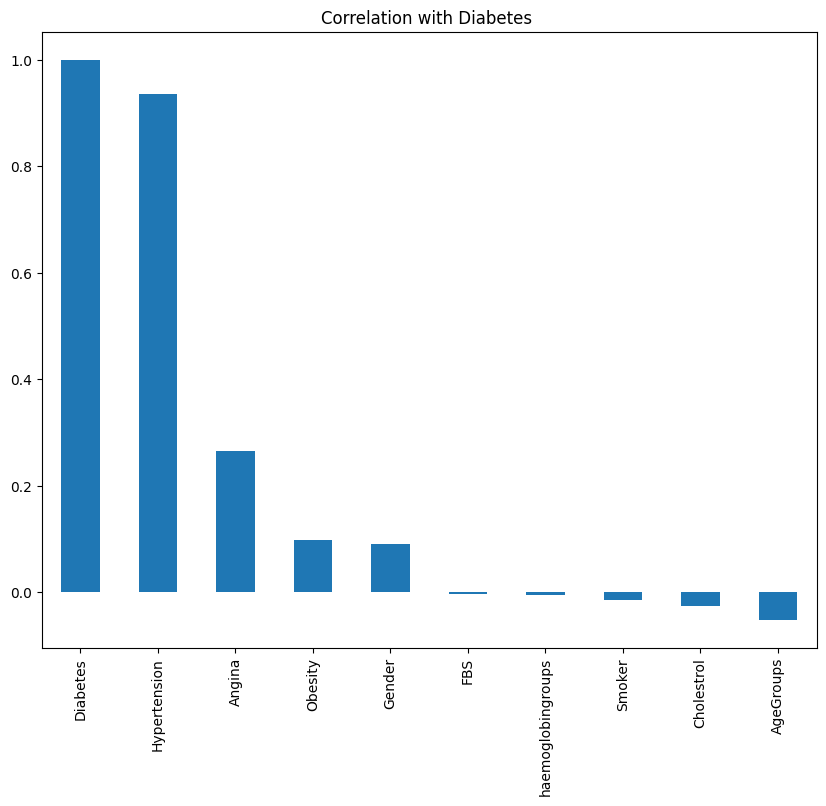

In [ ]:
plt.figure(figsize=(10,8))
cols=['Hypertension', 'Cholestrol', 'Obesity', 'Smoker', 'AgeGroups', 'haemoglobingroups', 'Angina', 'Gender', 'FBS']
df[cols+['Diabetes']].corr()['Diabetes'].sort_values(ascending=False).plot(kind='bar')
plt.title("Correlation with Diabetes ")
plt.show()

Correlation analysis indicates hypertension is the most strongly associated feature with diabetes, followed by angina and blood pressure.<br>Obesity shows moderate realtionship, while varaibles such as smoking, haemoglobin, and FBS exhibit negligible correaltion.

## Data Preprocessing

### Data Encoding


In [ ]:
df_model=df.copy()
binary = {1:1, 2:0}
colms=['Gender',	'Obesity', 'Diabetes',	'Hypertension','Blood_pressure',	'Smoker',	'Cholestrol', 'Angina',	 'AgeGroups',	'haemoglobingroups']
for col in colms:
  df_model[col]=df_model[col].map(binary)
df_model=pd.get_dummies(df_model, columns=['Cholestrol2'], drop_first=True)


### Data Splitting


In [ ]:
X=df_model.drop('Diabetes', axis=1)
y=df_model['Diabetes']
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, random_state=42)

### Class Balancing

In [ ]:
sm=SMOTE(random_state=42)
X_train_bal, y_train_bal=sm.fit_resample(X_train,y_train)


## Model Building

### (**A**)         Logistic Regression

#### Model Training

In [ ]:
lr_model=LogisticRegression(max_iter=100, class_weight="balanced")
lr_model.fit(X_train_bal, y_train_bal)
y_pred_lr=lr_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Model Evaluation

Accuracy score : 0.985
ROC_AUC score : 0.93699774991964
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       183
           1       0.94      0.88      0.91        17

    accuracy                           0.98       200
   macro avg       0.96      0.94      0.95       200
weighted avg       0.98      0.98      0.98       200



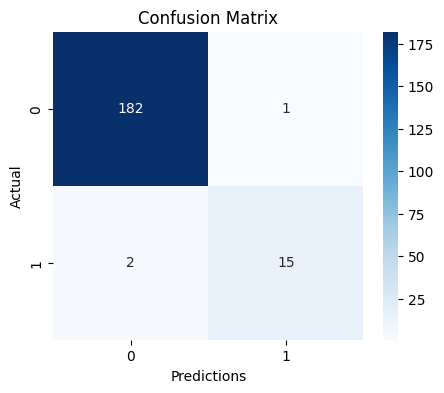

In [ ]:

print(f"Accuracy score : {accuracy_score(y_test , y_pred_lr)}")
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, thresholds = roc_curve(y_test, y_probs_lr)
auc_lr = roc_auc_score(y_test, y_probs_lr)
print(f"ROC_AUC score : {auc_lr}")
print(classification_report(y_test , y_pred_lr))
cm=confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True ,fmt='d' , cmap='Blues')
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### Interpretation


Logistic Regression model achieved high classfication performance with accuracy of 98% and ROC_AUC score of 0.936.<br>The model achieved a recall, precision and f1-score of 88%, 94% and 91% respectively for diabetic patients, indicating strong capability in identifying positive diabetic cases.

### (**B**) Decision Tree


#### Model Training

In [ ]:
dt_model=DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=5, min_samples_split=2,)
dt_model.fit(X_train_bal, y_train_bal)
y_pred_dt=dt_model.predict(X_test)

#### Model Evaluation

Accuracy score : 0.975
ROC_AUC score : 0.8629058180649308
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       183
           1       0.93      0.76      0.84        17

    accuracy                           0.97       200
   macro avg       0.95      0.88      0.91       200
weighted avg       0.97      0.97      0.97       200



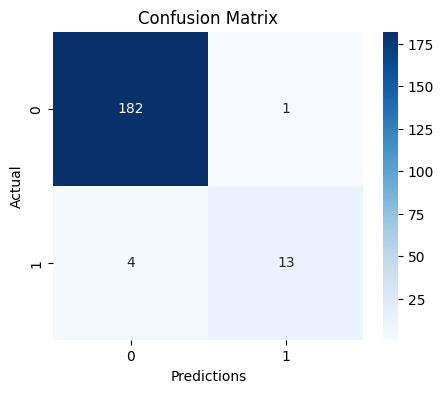

In [ ]:

print(f"Accuracy score : {accuracy_score(y_test , y_pred_dt)}")
y_probs_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds = roc_curve(y_test, y_probs_dt)
auc_dt = roc_auc_score(y_test, y_probs_dt)
print(f"ROC_AUC score : {auc_dt}")
print(classification_report(y_test , y_pred_dt))
cm=confusion_matrix(y_test,y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True ,fmt='d' , cmap='Blues')
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### Interpretation

The Decision Tree Classifier model achieved good classification performance with accuracy of 97.5% and ROC_AUC score of 0.86. <br>The model showed recall, precision and f1-score of 76%, 93%, 84% respectively, for diabetic patients. Thus, showing good capability of identifying positive diabetic cases but also moderate false positive predictions.

### (**C**) Random Forest Classifier

#### Model Training

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)
y_pred_rf=rf_model.predict(X_test)

#### Model Evaluation

Accuracy score : 0.985
ROC_AUC score : 0.9273545483767277
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       183
           1       0.94      0.88      0.91        17

    accuracy                           0.98       200
   macro avg       0.96      0.94      0.95       200
weighted avg       0.98      0.98      0.98       200



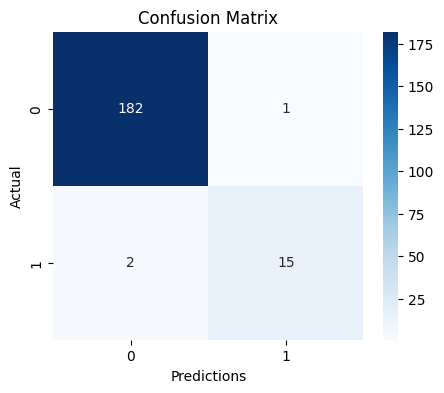

In [ ]:

print(f"Accuracy score : {accuracy_score(y_test , y_pred_rf)}")
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_probs_rf)
auc_rf = roc_auc_score(y_test, y_probs_rf)
print(f"ROC_AUC score : {auc_rf}")
print(classification_report(y_test , y_pred_rf))
cm=confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True ,fmt='d' , cmap='Blues')
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### Interpretation

The Random Forest Classifier model achieved great classification performance with accuracy of 98.5% and ROC_AUC score of 0.92. <br>The model showed recall, precision and f1-score of 88%, 94%, 91% respectively, for diabetic patients. Thus, showing strong capability of identifying positive diabetic cases.

### (**D**) XGBoost Classifier

#### Model Training

In [ ]:
xg_model=XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, min_samples_split=5, subsample=0.8, colsample_bytree=0.8, objective='binary:logistic', eval_metric='logloss',  random_state=42)
xg_model.fit(X_train_bal, y_train_bal)
y_pred_xg=xg_model.predict(X_test)

#### Model Evaluation

Accuracy score : 0.97
ROC_AUC score : 0.926711668273867
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       183
           1       0.79      0.88      0.83        17

    accuracy                           0.97       200
   macro avg       0.89      0.93      0.91       200
weighted avg       0.97      0.97      0.97       200



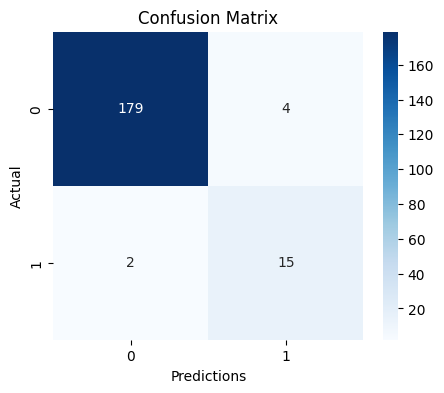

In [ ]:

print(f"Accuracy score : {accuracy_score(y_test , y_pred_xg)}")
y_probs_xg = xg_model.predict_proba(X_test)[:, 1]
fpr_xg, tpr_xg, thresholds = roc_curve(y_test, y_probs_xg)
auc_xg = roc_auc_score(y_test, y_probs_xg)
print(f"ROC_AUC score : {auc_xg}")
print(classification_report(y_test , y_pred_xg))
cm=confusion_matrix(y_test,y_pred_xg)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True ,fmt='d' , cmap='Blues')
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### Interpretation

The XGBoost Classifier model achieved great classification performance with accuracy of 97% and ROC_AUC score of 0.926. <br>The model showed recall, precision and f1-score of 88%, 79%, 83% respectively, for diabetic patients. Thus, showing strong capability of identifying positive diabetic cases.

### (**E**) Naive Bayes Classifier

#### Model Training

In [ ]:
nv_model=GaussianNB(priors=None, var_smoothing=1e-09)
nv_model.fit(X_train_bal, y_train_bal)
y_pred_nv=nv_model.predict(X_test)

#### Model Evaluation

Accuracy score : 0.975
ROC_AUC score : 0.8723882995821279
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       183
           1       0.88      0.82      0.85        17

    accuracy                           0.97       200
   macro avg       0.93      0.91      0.92       200
weighted avg       0.97      0.97      0.97       200



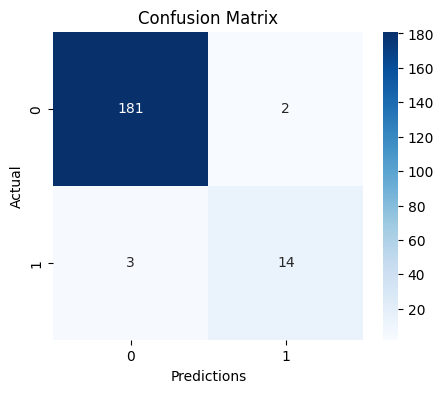

In [ ]:

print(f"Accuracy score : {accuracy_score(y_test , y_pred_nv)}")
y_probs_nv = nv_model.predict_proba(X_test)[:, 1]
fpr_nv, tpr_nv, thresholds = roc_curve(y_test, y_probs_nv)
auc_nv = roc_auc_score(y_test, y_probs_nv)
print(f"ROC_AUC score : {auc_nv}")
print(classification_report(y_test , y_pred_nv))
cm=confusion_matrix(y_test,y_pred_nv)
plt.figure(figsize=(5,4))
sns.heatmap(cm , annot=True ,fmt='d' , cmap='Blues')
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


#### Interpretation

The Naive Bayes Classifier model achieved great classification performance with accuracy of 97.5% and ROC_AUC score of 0.872. <br>The model showed recall, precision and f1-score of 82%, 88%, 85% respectively, for diabetic patients. Thus, showing strong capability of identifying positive diabetic cases.

## Comparative Analysis

### Combined ROC Curve

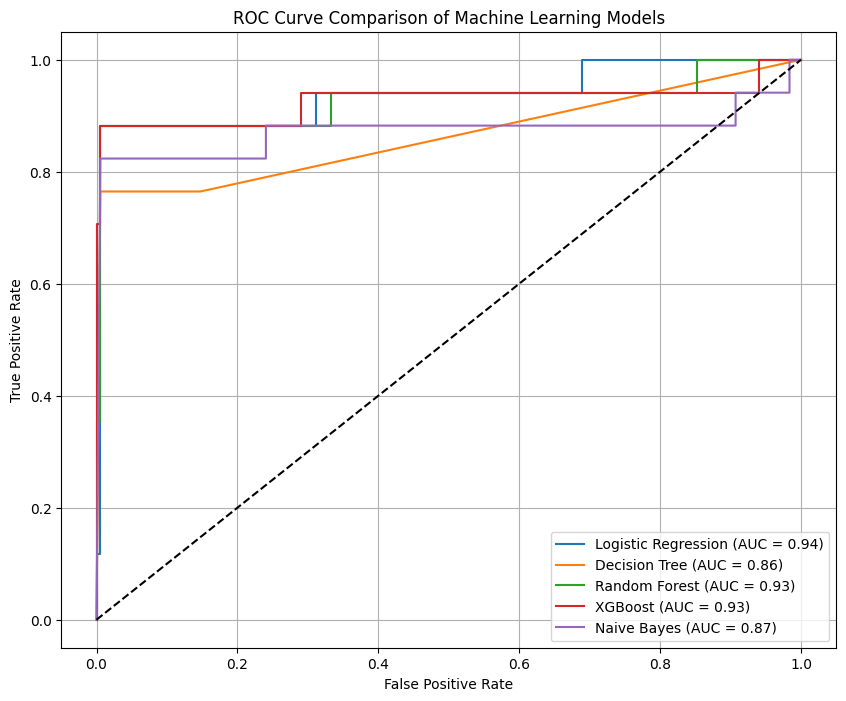

In [ ]:
plt.figure(figsize=(10,8))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.2f})')

plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC = {auc_dt:.2f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.2f})')

plt.plot(fpr_xg, tpr_xg,
         label=f'XGBoost (AUC = {auc_xg:.2f})')

plt.plot(fpr_nv, tpr_nv,
         label=f'Naive Bayes (AUC = {auc_nv:.2f})')

# Random classifier baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

The comparative ROC curve analysis demonstrates that Logistic Regression achieved the highest ROC_AUC score among all evaluated machine learning models.<br>
This indicates that Logistic Regression possesses the strongest capability to distinguish between diabetic and non-diabetic patients on the given clinical dataset.<br>
The ROC_AUC curve of Logistic Regression remains closest to the top-left corner, reflecting superior classification performance and a better sensitivity-specificity tradeoff compared to Decision Tree Classifier, Random Forest, XGBoost, and Naive Bayes Classifier.<br>
Although Random Forest and XGBoost also demonstrated strong predictive capability, Logistic Regression achieved the highest overall ROC_AUC score along with excellent accuracy, precision, recall, and F1-score performance.<br>
Therefore, according to the comparative ROC_AUC analysis, Logistic Regression can be considered the most effective model for diabetes prediction in this study.

### Evaluation Metrics Table



|Model|Accuracy|Precision|Recall|F1-score|ROC_AUC|
|----|----|----|----|----|----|
|Logistic Regression|98.5%|94%|88%|91%|0.936|
|Decision Tree|97.5%|93%|76%|84%|0.86|
|Random Forest|98.5%|94%|88%|91%|0.927|
|XGBoost|97%|79%|88%|83%|0.926|
|Naive Bayes|97.5%|88%|82%|85%|0.872|

## Conclusion

This study presented a comparative analysis of multiple machine learning algorithms for diabetes prediction using clinical patient data obtained from SGPGI Hospital. Various stages of data preprocessing and exploratory data analysis were performed, including univariate, bivariate, and multivariate analysis, handling of class imbalance using SMOTE, encoding of categorical variables, and model evaluation using standard classification metrics.<br>
Five machine learning models, namely Logistic Regression, Decision Tree, Random Forest, XGBoost, and Naive Bayes, were trained and evaluated using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC score.<br>
Among all evaluated classifiers, Logistic Regression achieved the highest ROC-AUC score of 0.936 along with excellent classification accuracy and balanced precision-recall performance, indicating superior capability in distinguishing diabetic and non-diabetic patients. Random Forest also demonstrated strong predictive performance with comparable accuracy and F1-score values, while Decision Tree and Naive Bayes showed comparatively lower performance.<br>
The results indicate that simpler linear classification approaches such as Logistic Regression can perform exceptionally well on structured clinical datasets when appropriate preprocessing and class balancing techniques are applied. The proposed comparative framework can assist in early diabetes prediction and may contribute toward intelligent clinical decision support systems.
<br>
Although ensemble-based models such as Random Forest and XGBoost demonstrated strong predictive capability, Logistic Regression achieved the best overall balance between accuracy, interpretability, precision, recall, F1-score, and ROC-AUC performance on the cleaned dataset.
<br>
Hence, based on comparative evaluation metrics and ROC_AUC analysis, ***Logistic Regression*** emerged as the best-performing model for diabetes prediction in this study.
